In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Load featured dataset
file_path = os.path.join('..', 'data', 'processed', 'josaa_featured.csv')
df = pd.read_csv(file_path)

print(f"Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Global Style Configuration ──────────────────────────────
# We define everything once here so all charts are consistent
# Think of this as your project's visual design system

plt.rcParams.update({
    'figure.dpi'         : 150,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#F8F9FA',
    'axes.grid'          : True,
    'grid.color'         : '#E0E0E0',
    'grid.linewidth'     : 0.8,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.titlepad'      : 15,
    'axes.labelsize'     : 11,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'legend.fontsize'    : 9,
    'legend.framealpha'  : 0.9,
    'font.family'        : 'DejaVu Sans',
})

# ── Color Palettes ───────────────────────────────────────────
INSTITUTE_COLORS = {
    'IIT'  : '#C62828',
    'NIT'  : '#1565C0',
    'IIIT' : '#2E7D32',
    'GFTI' : '#E65100'
}

CATEGORY_COLORS = {
    'OPEN'   : '#1565C0',
    'EWS'    : '#2E7D32',
    'OBC-NCL': '#F57F17',
    'SC'     : '#6A1B9A',
    'ST'     : '#B71C1C'
}

FIGURES_PATH = os.path.join('..', 'reports', 'figures')

def save_fig(filename, tight=True):
    """Helper to save every figure consistently"""
    path = os.path.join(FIGURES_PATH, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight' if tight else None,
                facecolor='white')
    print(f"Saved: {filename}")

print("Global style configured.")

Data loaded: 432,524 rows, 23 columns
Global style configured.


In [3]:
# We recreate our analysis subsets from Phase 5
# All visualizations use one of these subsets

# Last round per institute type per year
last_round_per_type_year = (
    df[
        (df['is_special_round'] == False) &
        (df['quota'] == 'AI')
    ]
    .groupby(['year', 'institute_type'])['round']
    .max()
    .reset_index()
    .rename(columns={'round': 'last_round'})
)

df_with_last = df.merge(
    last_round_per_type_year,
    on=['year', 'institute_type'],
    how='left'
)

# Main analysis subset — IIT, IIIT, GFTI
df_eda = df_with_last[
    (df_with_last['round'] == df_with_last['last_round']) &
    (df_with_last['is_special_round'] == False) &
    (df_with_last['quota'] == 'AI') &
    (df_with_last['is_pwd'] == False) &
    (df_with_last['gender_short'] == 'GN') &
    (df_with_last['institute_type'].isin(['IIT', 'IIIT', 'GFTI']))
].copy()

# NIT subset
last_round_nit = (
    df[
        (df['is_special_round'] == False) &
        (df['quota'].isin(['OS', 'AI'])) &
        (df['institute_type'] == 'NIT')
    ]
    .groupby('year')['round']
    .max()
    .reset_index()
    .rename(columns={'round': 'last_round'})
)

df_with_last_nit = df.merge(last_round_nit, on='year', how='left')

df_eda_nit = df_with_last_nit[
    (df_with_last_nit['round'] == df_with_last_nit['last_round']) &
    (df_with_last_nit['is_special_round'] == False) &
    (df_with_last_nit['quota'].isin(['OS', 'AI'])) &
    (df_with_last_nit['institute_type'] == 'NIT') &
    (df_with_last_nit['is_pwd'] == False) &
    (df_with_last_nit['gender_short'] == 'GN')
].copy()

# Combined
comp_eda = pd.concat([df_eda, df_eda_nit], ignore_index=True)

# Category subset
df_category = df_with_last[
    (df_with_last['round'] == df_with_last['last_round']) &
    (df_with_last['is_special_round'] == False) &
    (df_with_last['quota'] == 'AI') &
    (df_with_last['is_pwd'] == False) &
    (df_with_last['gender_short'] == 'GN')
].copy()

print(f"comp_eda    : {len(comp_eda):,} rows")
print(f"df_category : {len(df_category):,} rows")

comp_eda    : 27,802 rows
df_category : 19,422 rows


In [4]:
# Name shorteners — reused across all charts
def shorten_name(name):
    replacements = {
        'Indian Institute of Technology '                          : 'IIT ',
        'National Institute of Technology '                        : 'NIT ',
        'National Institute of Technology, '                       : 'NIT ',
        'Indian Institute of Information Technology '              : 'IIIT ',
        'Indian Institute of Information Technology, '             : 'IIIT ',
        'International Institute of Information Technology, '      : 'IIIT Int. ',
        'Atal Bihari Vajpayee Indian Institute of Information Technology & Management ' : 'ABV IIITM ',
        'Malaviya National Institute of Technology '               : 'Malaviya NIT ',
        'Maulana Azad National Institute of Technology '           : 'Maulana Azad NIT ',
        'Motilal Nehru National Institute of Technology '          : 'Motilal Nehru NIT ',
        'Visvesvaraya National Institute of Technology, '          : 'VNIT ',
        'Sardar Vallabhbhai National Institute of Technology, '    : 'SVNIT ',
        'Dr. B R Ambedkar National Institute of Technology, '      : 'NIT ',
    }
    for full, short in replacements.items():
        name = name.replace(full, short)
    return name

import re
def shorten_program(name):
    is_dual = 'Bachelor and Master' in name or 'Dual Degree' in name
    cleaned = name
    while '(' in cleaned:
        cleaned = re.sub(r'\([^()]*\)', '', cleaned)
    cleaned = cleaned.strip().rstrip(')').strip()
    replacements = {
        'Computer Science and Engineering' : 'CSE',
        'Electronics and Communication Engineering' : 'ECE',
        'Electrical Engineering' : 'EE',
        'Mechanical Engineering' : 'ME',
        'Civil Engineering' : 'CE',
        'Chemical Engineering' : 'ChE',
        'Mathematics and Computing' : 'Math & Computing',
        'Engineering Physics' : 'Engg Physics',
        'Aerospace Engineering' : 'Aerospace',
        'Artificial Intelligence' : 'AI',
        'Data Science and Artificial Intelligence' : 'DS & AI',
        'Artificial Intelligence and Data Science' : 'AI & DS',
        'Information Technology' : 'IT',
        'Metallurgical and Materials Engineering' : 'Met & Materials',
        'Mining Engineering' : 'Mining Engg',
        'Electronics and Instrumentation Engineering' : 'EIE',
        'Energy Engineering' : 'Energy Engg',
        'Materials Engineering' : 'Materials Engg',
    }
    short = replacements.get(cleaned, cleaned)
    if is_dual:
        short = short + ' (DD)'
    return short

print("Helper functions ready.")

Helper functions ready.


Saved: V1_institute_type_competitiveness.png


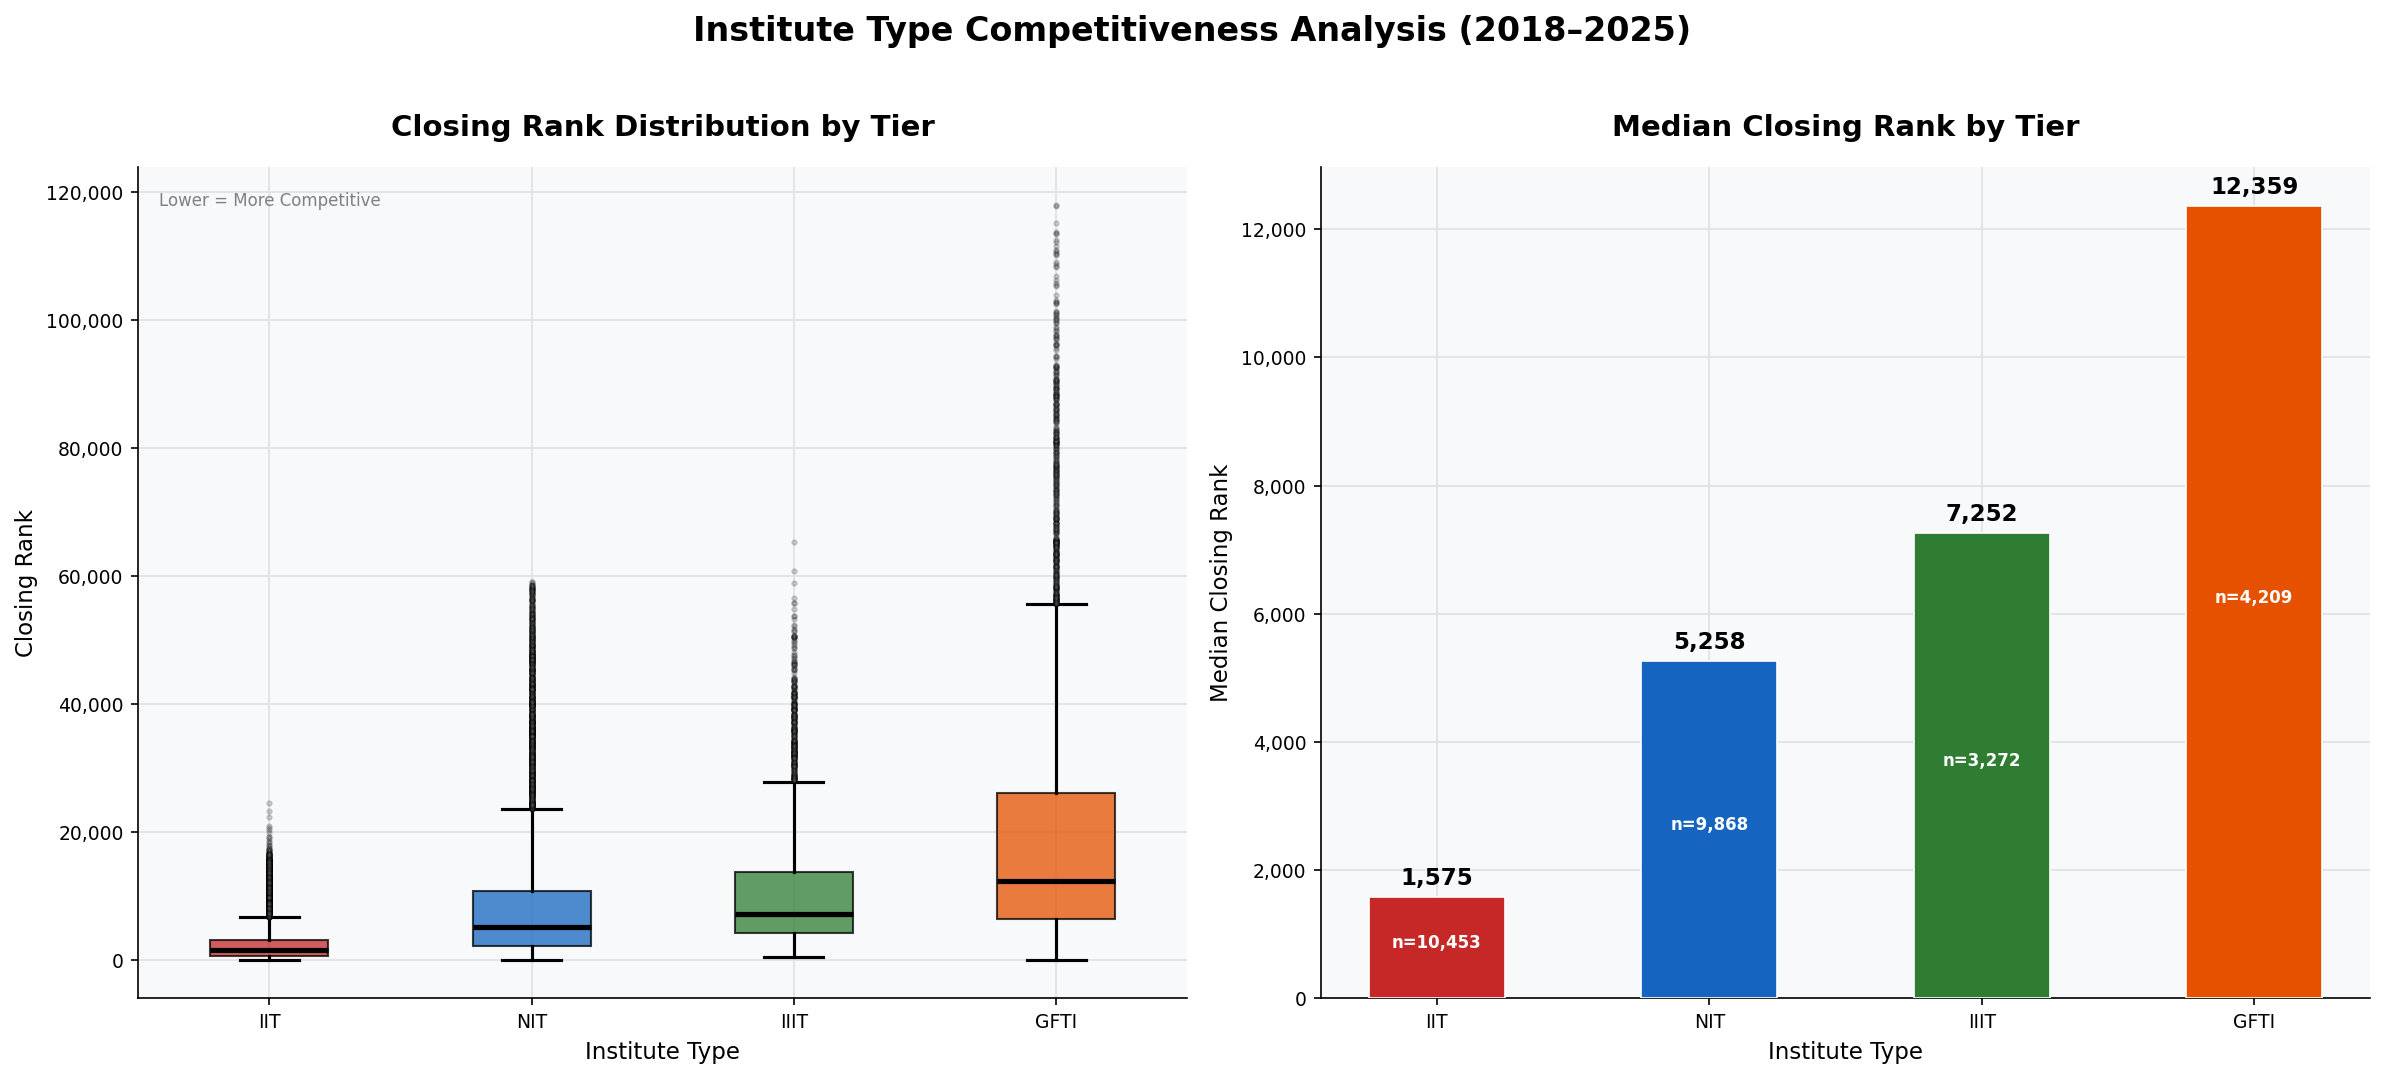

In [5]:
# CHART PURPOSE: Answer "Which tier is most competitive?"
# CHART TYPE: Side by side — Box plot + Bar chart
# WHY BOX PLOT: Shows full distribution, not just average
# WHY BAR CHART: Gives exact median number for quick reading

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    'Institute Type Competitiveness Analysis (2018–2025)',
    fontsize=16, fontweight='bold', y=1.02
)

order    = ['IIT', 'NIT', 'IIIT', 'GFTI']
colors   = [INSTITUTE_COLORS[t] for t in order]
medians  = [comp_eda[comp_eda['institute_type']==t]['closing_rank'].median()
            for t in order]
counts   = [comp_eda[comp_eda['institute_type']==t]['closing_rank'].count()
            for t in order]

# ── Left: Box Plot ───────────────────────────────────────────
bp = axes[0].boxplot(
    [comp_eda[comp_eda['institute_type']==t]['closing_rank'].values
     for t in order],
    labels=order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='gray',
                    markersize=2, alpha=0.2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

axes[0].set_title('Closing Rank Distribution by Tier')
axes[0].set_xlabel('Institute Type')
axes[0].set_ylabel('Closing Rank')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}')
)
axes[0].annotate(
    'Lower = More Competitive',
    xy=(0.02, 0.97), xycoords='axes fraction',
    fontsize=8, color='gray', va='top'
)

# ── Right: Median Bar Chart ──────────────────────────────────
bars = axes[1].bar(
    order, medians, color=colors,
    edgecolor='white', linewidth=0.8,
    width=0.5, zorder=3
)

for bar, val, n in zip(bars, medians, counts):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{int(val):,}',
        ha='center', fontsize=11, fontweight='bold'
    )
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f'n={n:,}',
        ha='center', fontsize=8, color='white', fontweight='bold'
    )

axes[1].set_title('Median Closing Rank by Tier')
axes[1].set_xlabel('Institute Type')
axes[1].set_ylabel('Median Closing Rank')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}')
)

plt.tight_layout()
save_fig('V1_institute_type_competitiveness.png')
plt.show()

Saved: V2_top20_colleges.png


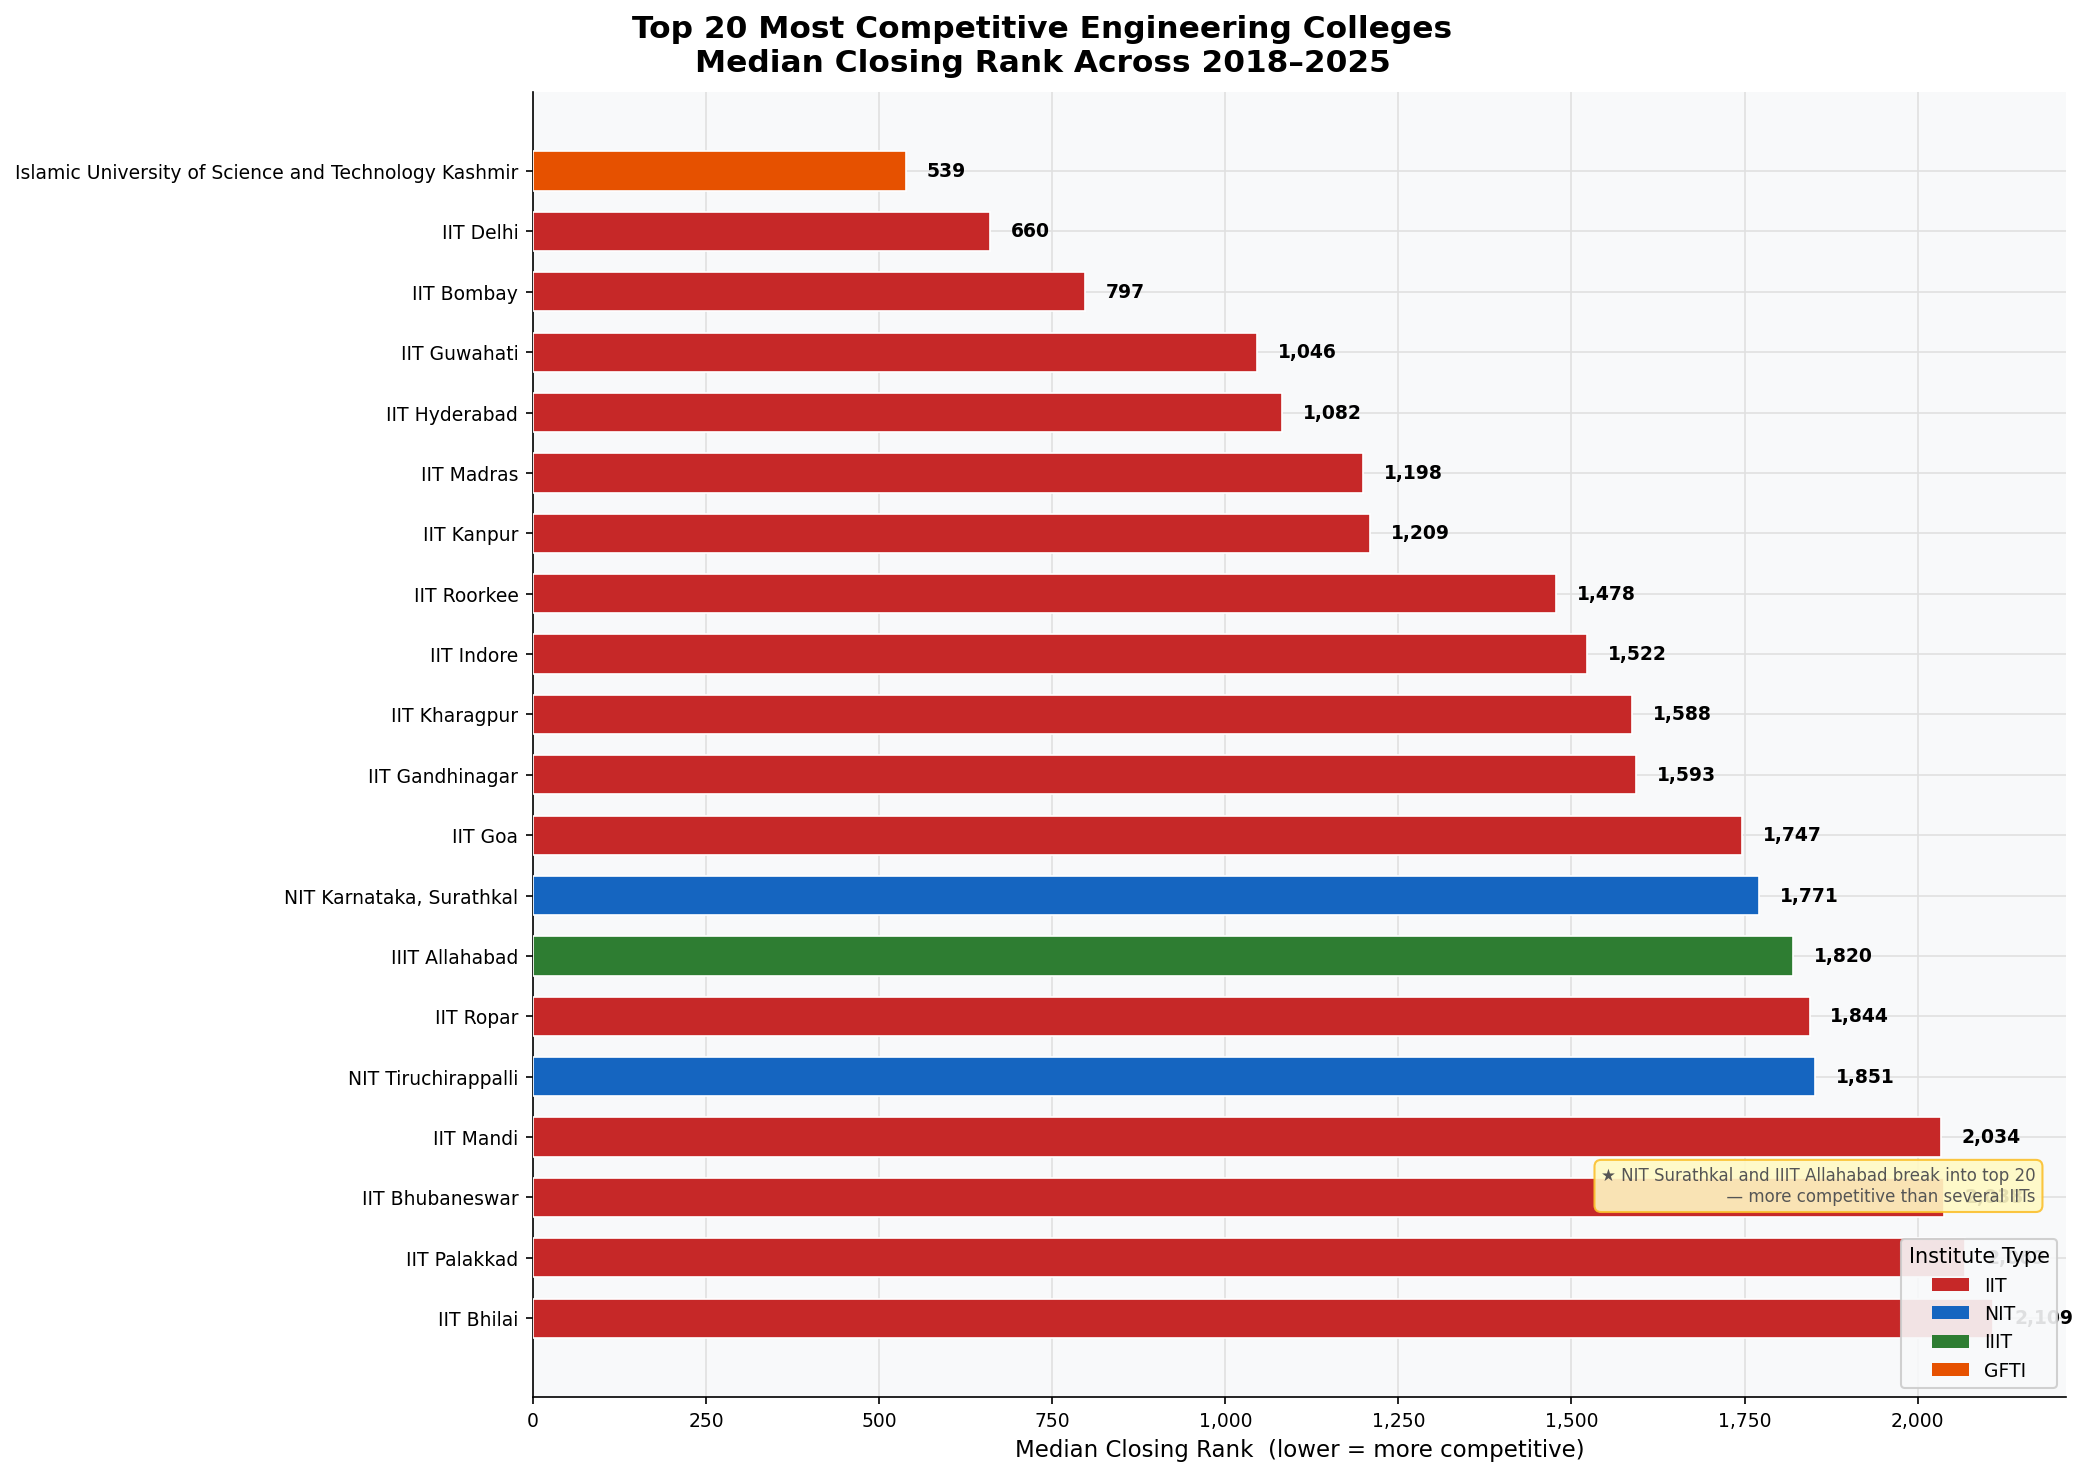

In [6]:
# CHART PURPOSE: Answer "Which individual colleges are most competitive?"
# CHART TYPE: Horizontal bar — best for ranked lists with long labels
# COLOR: By institute type — immediately shows tier distribution in top 20

arch_pattern = 'Architecture|Planning'

college_rank = (
    comp_eda[
        ~comp_eda['institute'].str.contains(arch_pattern, case=False, na=False)
    ]
    .groupby(['institute', 'institute_type'])['closing_rank']
    .agg(median_closing='median', years_present=('nunique'))
    .reset_index()
    .query('years_present >= 3')
    .sort_values('median_closing')
    .head(20)
)

college_rank['short_name'] = college_rank['institute'].apply(shorten_name)
colors_v2 = [INSTITUTE_COLORS[t] for t in college_rank['institute_type']]

fig, ax = plt.subplots(figsize=(14, 10))
fig.suptitle(
    'Top 20 Most Competitive Engineering Colleges\n'
    'Median Closing Rank Across 2018–2025',
    fontsize=15, fontweight='bold'
)

bars = ax.barh(
    college_rank['short_name'],
    college_rank['median_closing'],
    color=colors_v2, edgecolor='white',
    linewidth=0.8, height=0.65, zorder=3
)

for bar, val, itype in zip(
    bars, college_rank['median_closing'],
    college_rank['institute_type']
):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height()/2,
        f'{int(val):,}',
        va='center', fontsize=9, fontweight='bold'
    )

ax.set_xlabel('Median Closing Rank  (lower = more competitive)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}')
)

legend_els = [
    mpatches.Patch(facecolor=INSTITUTE_COLORS[t], label=t)
    for t in ['IIT', 'NIT', 'IIIT', 'GFTI']
]
ax.legend(handles=legend_els, title='Institute Type',
          loc='lower right', framealpha=0.9)

ax.annotate(
    '★ NIT Surathkal and IIIT Allahabad break into top 20\n'
    '  — more competitive than several IITs',
    xy=(0.98, 0.15), xycoords='axes fraction',
    ha='right', fontsize=8, color='#555',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4',
              edgecolor='#FBC02D', alpha=0.9)
)

plt.tight_layout()
save_fig('V2_top20_colleges.png')
plt.show()

Saved: V3_yoy_trend_by_type.png


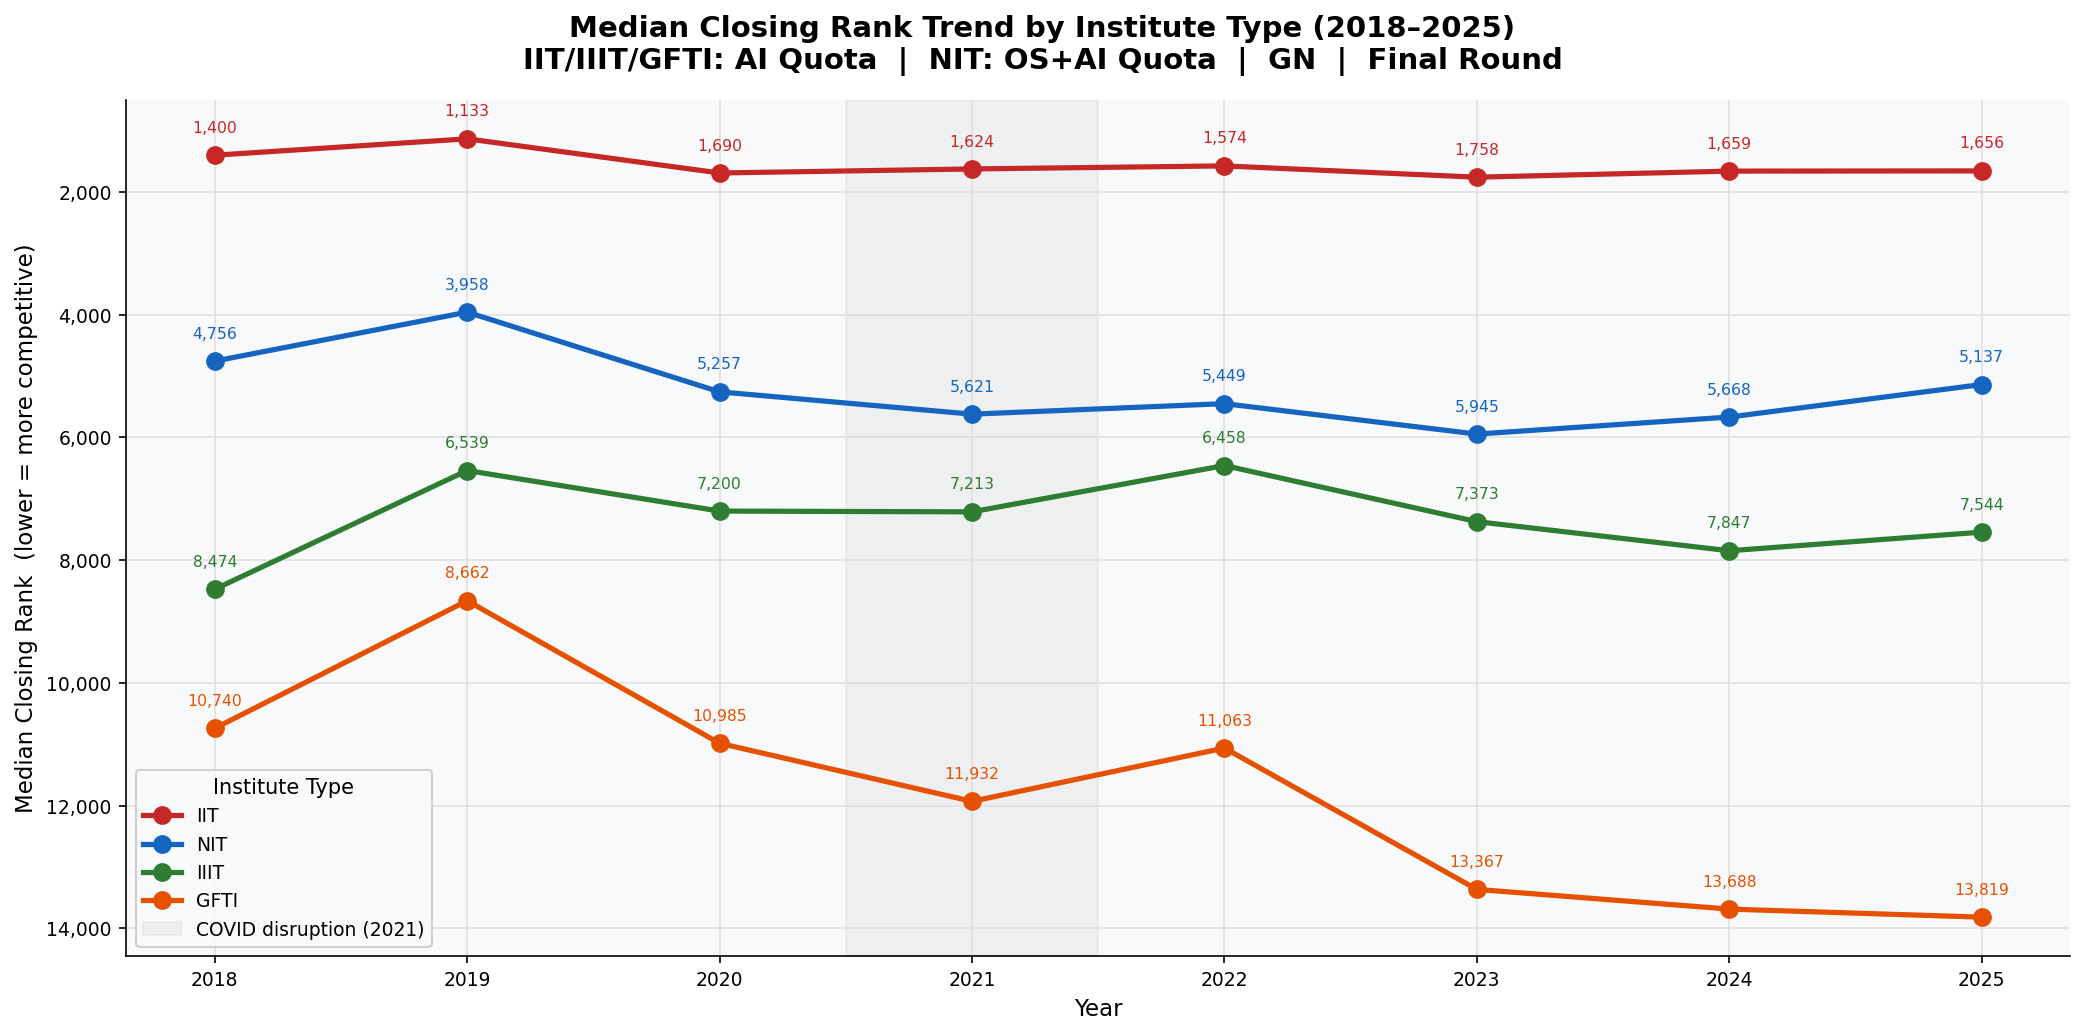

In [7]:
# CHART PURPOSE: Show how competition evolved across 8 years per tier
# CHART TYPE: Multi-line with annotations
# WHY INVERTED Y-AXIS: Lower rank = more competitive, should appear higher

trend = (
    comp_eda
    .groupby(['year', 'institute_type'])['closing_rank']
    .median().reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle(
    'Median Closing Rank Trend by Institute Type (2018–2025)\n'
    'IIT/IIIT/GFTI: AI Quota  |  NIT: OS+AI Quota  |  GN  |  Final Round',
    fontsize=14, fontweight='bold'
)

for itype in ['IIT', 'NIT', 'IIIT', 'GFTI']:
    data = trend[trend['institute_type'] == itype].sort_values('year')
    ax.plot(
        data['year'], data['closing_rank'],
        marker='o', linewidth=2.5, markersize=8,
        label=itype, color=INSTITUTE_COLORS[itype], zorder=3
    )
    for _, row in data.iterrows():
        ax.annotate(
            f"{int(row['closing_rank']):,}",
            (row['year'], row['closing_rank']),
            textcoords='offset points',
            xytext=(0, 11), ha='center',
            fontsize=7.5, color=INSTITUTE_COLORS[itype]
        )

# Highlight COVID year
ax.axvspan(2020.5, 2021.5, alpha=0.08, color='gray',
           label='COVID disruption (2021)')

ax.set_xlabel('Year')
ax.set_ylabel('Median Closing Rank  (lower = more competitive)')
ax.set_xticks(sorted(comp_eda['year'].unique()))
ax.legend(title='Institute Type', loc='lower left')
ax.invert_yaxis()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}')
)

plt.tight_layout()
save_fig('V3_yoy_trend_by_type.png')
plt.show()

Saved: V4_category_gap_analysis.png


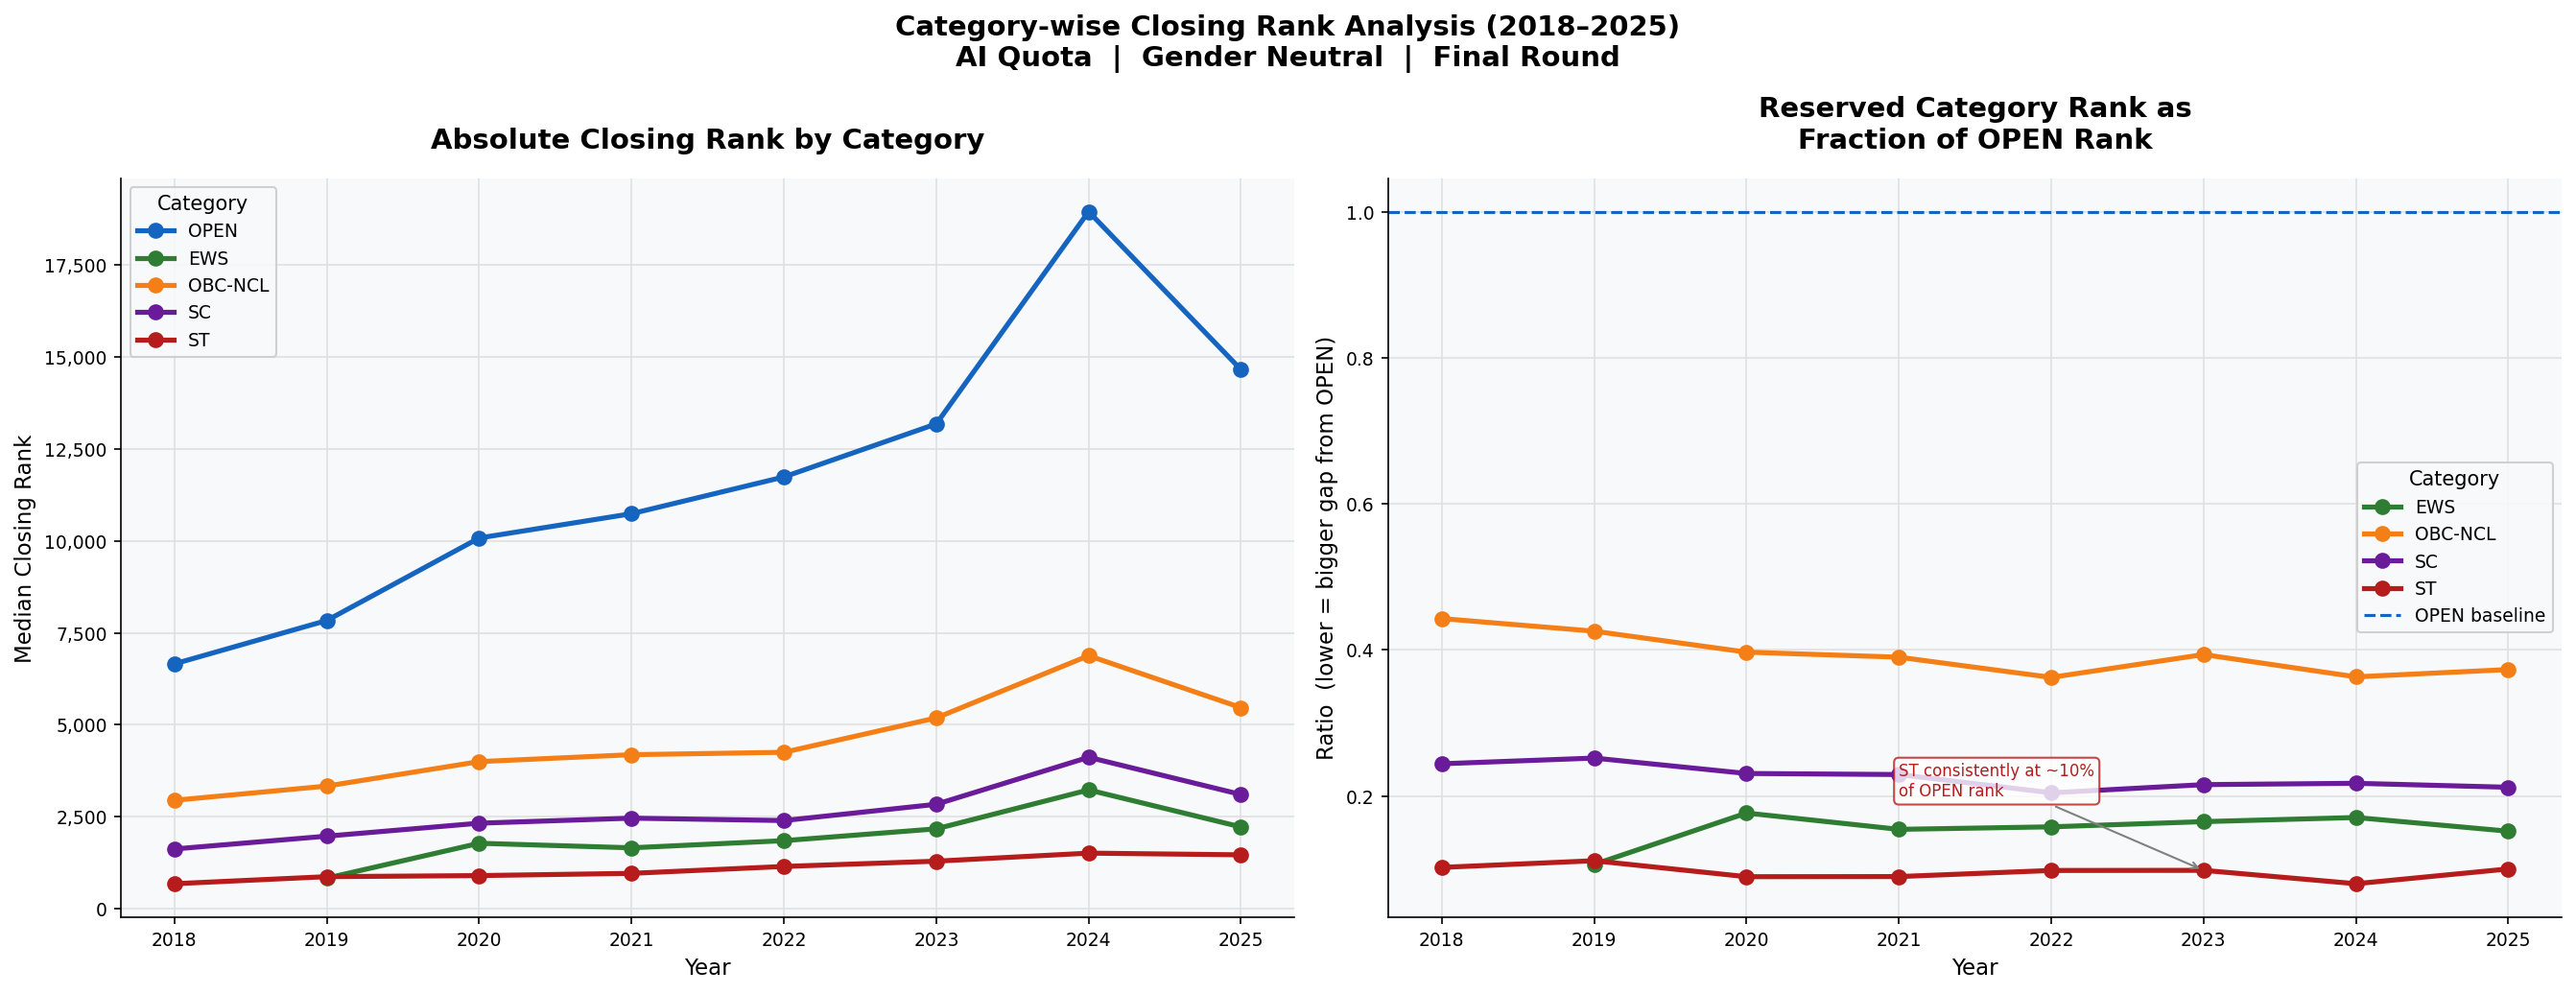

In [8]:
# CHART PURPOSE: Show reservation category rank gaps
# CHART TYPE: Multi-line — each category is one line
# KEY INSIGHT: Gap between OPEN and ST consistently 10x

cat_order  = ['OPEN', 'EWS', 'OBC-NCL', 'SC', 'ST']

cat_trend = (
    df_category
    .groupby(['year', 'category_base'])['closing_rank']
    .median().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Category-wise Closing Rank Analysis (2018–2025)\n'
    'AI Quota  |  Gender Neutral  |  Final Round',
    fontsize=14, fontweight='bold'
)

# ── Left: Absolute trend ─────────────────────────────────────
for cat in cat_order:
    data = cat_trend[cat_trend['category_base']==cat].sort_values('year')
    axes[0].plot(
        data['year'], data['closing_rank'],
        marker='o', linewidth=2.5, markersize=7,
        label=cat, color=CATEGORY_COLORS[cat], zorder=3
    )

axes[0].set_title('Absolute Closing Rank by Category')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Closing Rank')
axes[0].set_xticks(sorted(df_category['year'].unique()))
axes[0].legend(title='Category')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}')
)

# ── Right: Gap ratio ─────────────────────────────────────────
pivot = cat_trend.pivot(
    index='year', columns='category_base', values='closing_rank'
)
gap = pivot.div(pivot['OPEN'], axis=0)

for cat in ['EWS', 'OBC-NCL', 'SC', 'ST']:
    axes[1].plot(
        gap.index, gap[cat],
        marker='o', linewidth=2.5, markersize=7,
        label=cat, color=CATEGORY_COLORS[cat], zorder=3
    )

axes[1].axhline(y=1.0, color=CATEGORY_COLORS['OPEN'],
                linestyle='--', linewidth=1.5, label='OPEN baseline')

axes[1].set_title('Reserved Category Rank as\nFraction of OPEN Rank')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Ratio  (lower = bigger gap from OPEN)')
axes[1].set_xticks(sorted(df_category['year'].unique()))
axes[1].legend(title='Category')

axes[1].annotate(
    'ST consistently at ~10%\nof OPEN rank',
    xy=(2023, gap.loc[2023, 'ST']),
    xytext=(2021, 0.2),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=8, color=CATEGORY_COLORS['ST'],
    bbox=dict(boxstyle='round', facecolor='white',
              edgecolor=CATEGORY_COLORS['ST'], alpha=0.8)
)

plt.tight_layout()
save_fig('V4_category_gap_analysis.png')
plt.show()

Saved: V5_branch_tier_heatmap.png


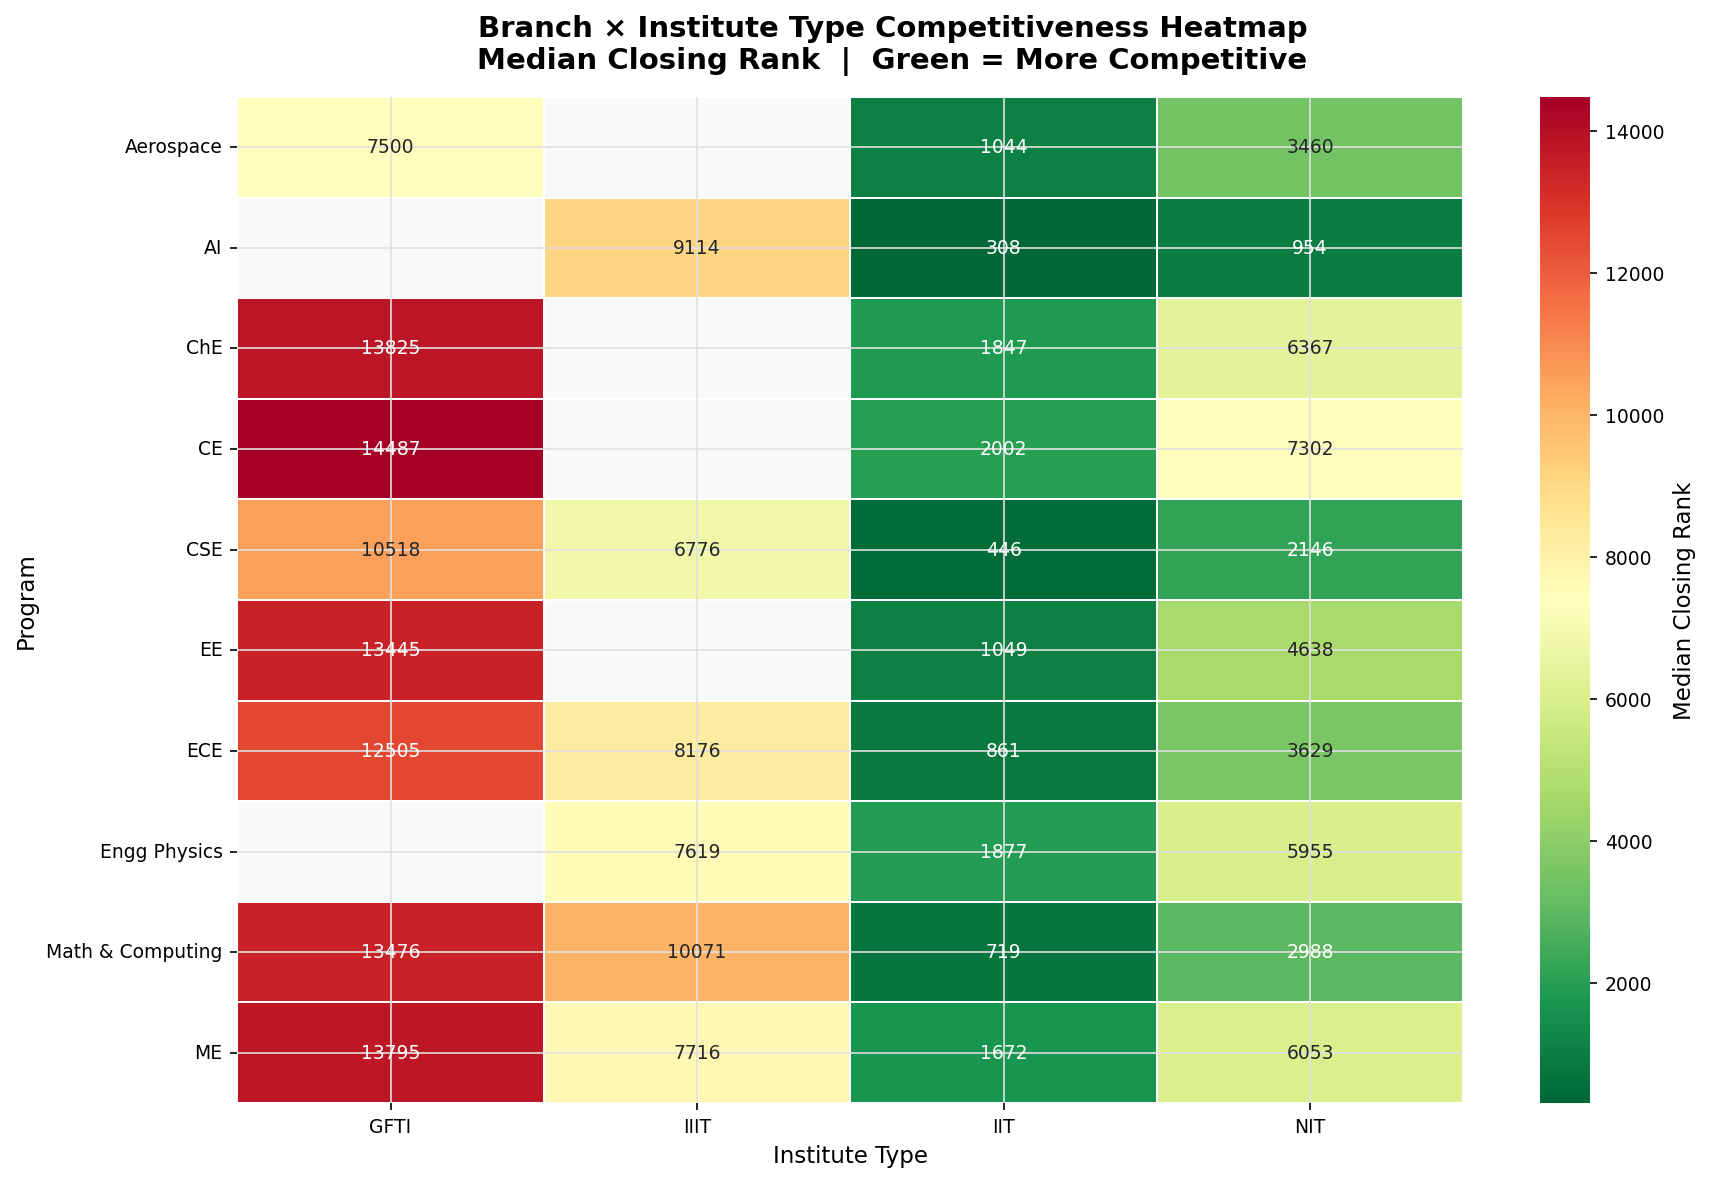

In [9]:
# CHART PURPOSE: Show competitiveness across branch × tier combinations
# CHART TYPE: Heatmap — best for two-dimensional categorical comparison
# INSIGHT: Shows which branch is competitive at which tier

top_programs = [
    'Artificial Intelligence (4 Years, Bachelor of Technology)',
    'Mathematics and Computing (4 Years, Bachelor of Technology)',
    'Aerospace Engineering (4 Years, Bachelor of Technology)',
    'Engineering Physics (4 Years, Bachelor of Technology)',
    'Electrical Engineering (4 Years, Bachelor of Technology)',
    'Computer Science and Engineering (4 Years, Bachelor of Technology)',
    'Electronics and Communication Engineering (4 Years, Bachelor of Technology)',
    'Mechanical Engineering (4 Years, Bachelor of Technology)',
    'Civil Engineering (4 Years, Bachelor of Technology)',
    'Chemical Engineering (4 Years, Bachelor of Technology)',
]

heatmap_data = (
    comp_eda[comp_eda['program'].isin(top_programs)]
    .groupby(['program', 'institute_type'])['closing_rank']
    .median()
    .unstack()
    .round(0)
)

heatmap_data.index = heatmap_data.index.map(shorten_program)

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle(
    'Branch × Institute Type Competitiveness Heatmap\n'
    'Median Closing Rank  |  Green = More Competitive',
    fontsize=14, fontweight='bold'
)

sns.heatmap(
    heatmap_data,
    annot=True, fmt='.0f',
    cmap='RdYlGn_r',
    linewidths=0.8, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Median Closing Rank'},
    annot_kws={'size': 9}
)

ax.set_xlabel('Institute Type')
ax.set_ylabel('Program')
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
save_fig('V5_branch_tier_heatmap.png')
plt.show()

Saved: V6_old_vs_new_iit_gap.png


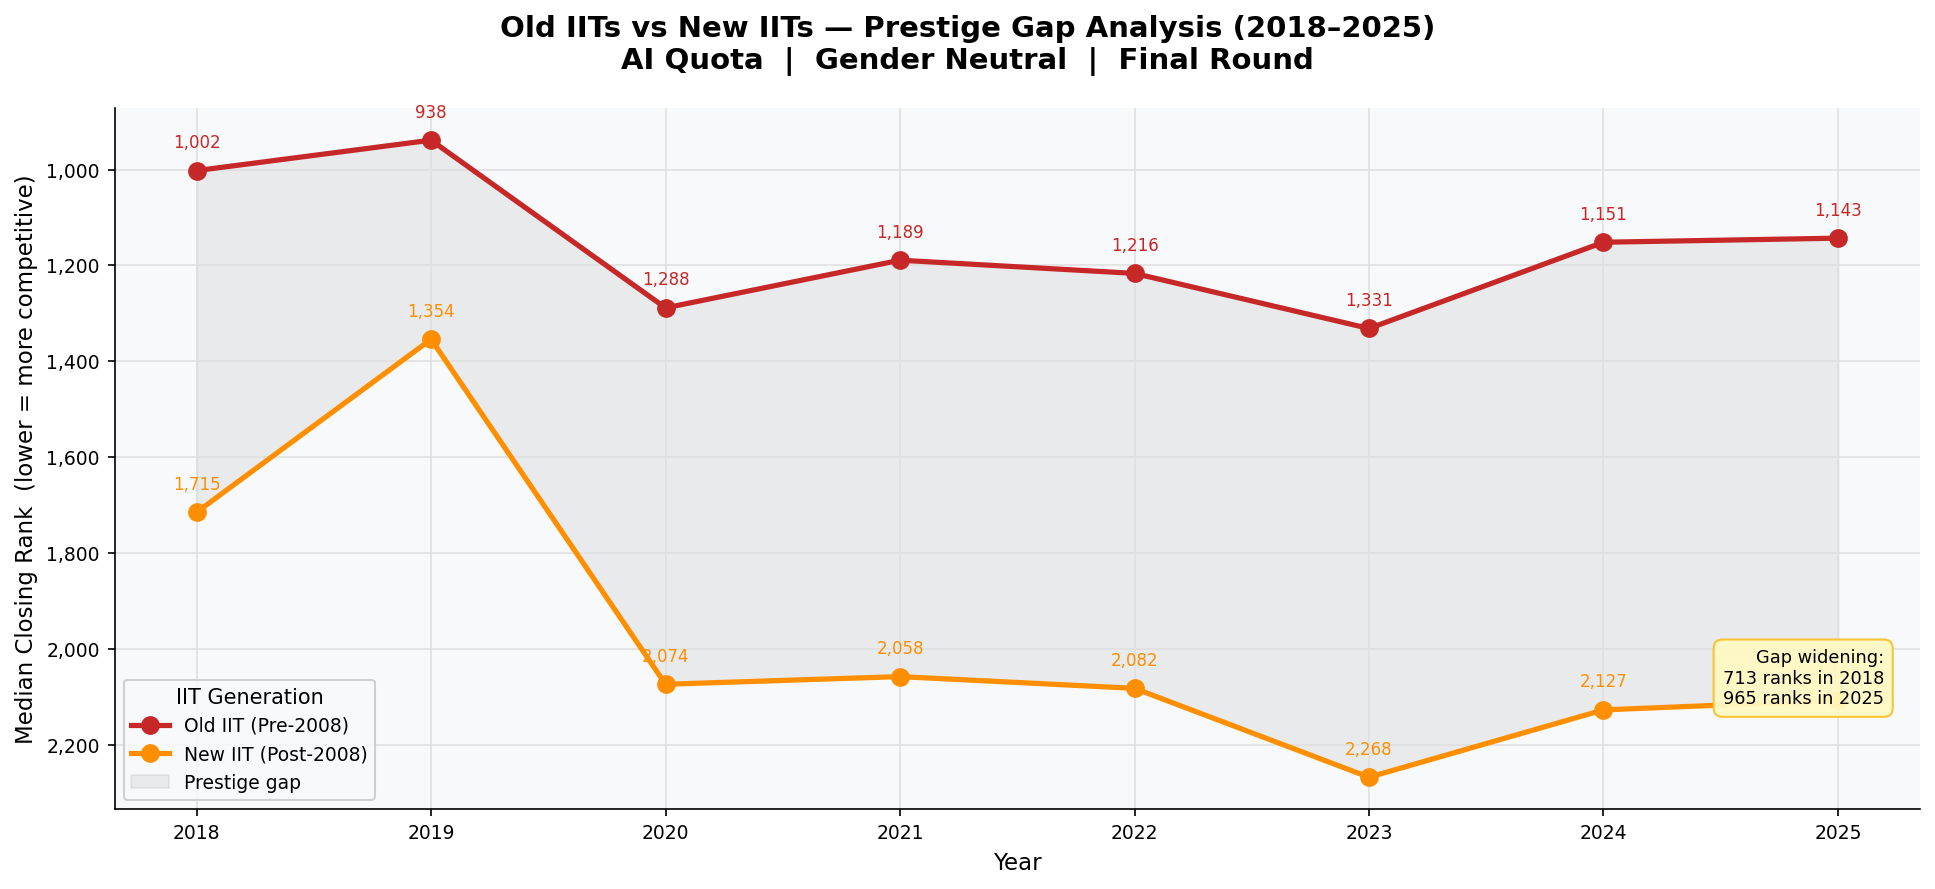

In [10]:
# CHART PURPOSE: Is the old vs new IIT prestige gap closing?
# CHART TYPE: Dual line with shaded area between them
# INSIGHT: Gap is widening, not closing

old_iits = [
    'Indian Institute of Technology Bombay',
    'Indian Institute of Technology Delhi',
    'Indian Institute of Technology Kanpur',
    'Indian Institute of Technology Kharagpur',
    'Indian Institute of Technology Madras',
    'Indian Institute of Technology Roorkee',
    'Indian Institute of Technology Guwahati'
]

iit_data = comp_eda[comp_eda['institute_type'] == 'IIT'].copy()
iit_data['generation'] = iit_data['institute'].apply(
    lambda x: 'Old IIT (Pre-2008)' if x in old_iits else 'New IIT (Post-2008)'
)

gen_trend = (
    iit_data.groupby(['year', 'generation'])['closing_rank']
    .median().reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle(
    'Old IITs vs New IITs — Prestige Gap Analysis (2018–2025)\n'
    'AI Quota  |  Gender Neutral  |  Final Round',
    fontsize=14, fontweight='bold'
)

colors_gen = {
    'Old IIT (Pre-2008)' : '#C62828',
    'New IIT (Post-2008)': '#FF8F00'
}

old_vals, new_vals, years = [], [], []

for gen, color in colors_gen.items():
    data = gen_trend[gen_trend['generation']==gen].sort_values('year')
    ax.plot(
        data['year'], data['closing_rank'],
        marker='o', linewidth=2.5, markersize=8,
        label=gen, color=color, zorder=3
    )
    for _, row in data.iterrows():
        ax.annotate(
            f"{int(row['closing_rank']):,}",
            (row['year'], row['closing_rank']),
            textcoords='offset points',
            xytext=(0, 11), ha='center',
            fontsize=8, color=color
        )
    if gen == 'Old IIT (Pre-2008)':
        old_vals = data.set_index('year')['closing_rank']
    else:
        new_vals = data.set_index('year')['closing_rank']
        years    = data['year'].values

# Shade the gap between old and new
ax.fill_between(
    years,
    old_vals.reindex(years).values,
    new_vals.reindex(years).values,
    alpha=0.12, color='gray',
    label='Prestige gap'
)

ax.set_xlabel('Year')
ax.set_ylabel('Median Closing Rank  (lower = more competitive)')
ax.set_xticks(sorted(iit_data['year'].unique()))
ax.legend(title='IIT Generation')
ax.invert_yaxis()
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}')
)

ax.annotate(
    'Gap widening:\n713 ranks in 2018\n965 ranks in 2025',
    xy=(0.98, 0.15), xycoords='axes fraction',
    ha='right', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF9C4',
              edgecolor='#FBC02D', alpha=0.95)
)

plt.tight_layout()
save_fig('V6_old_vs_new_iit_gap.png')
plt.show()

Saved: V7_gender_analysis.png


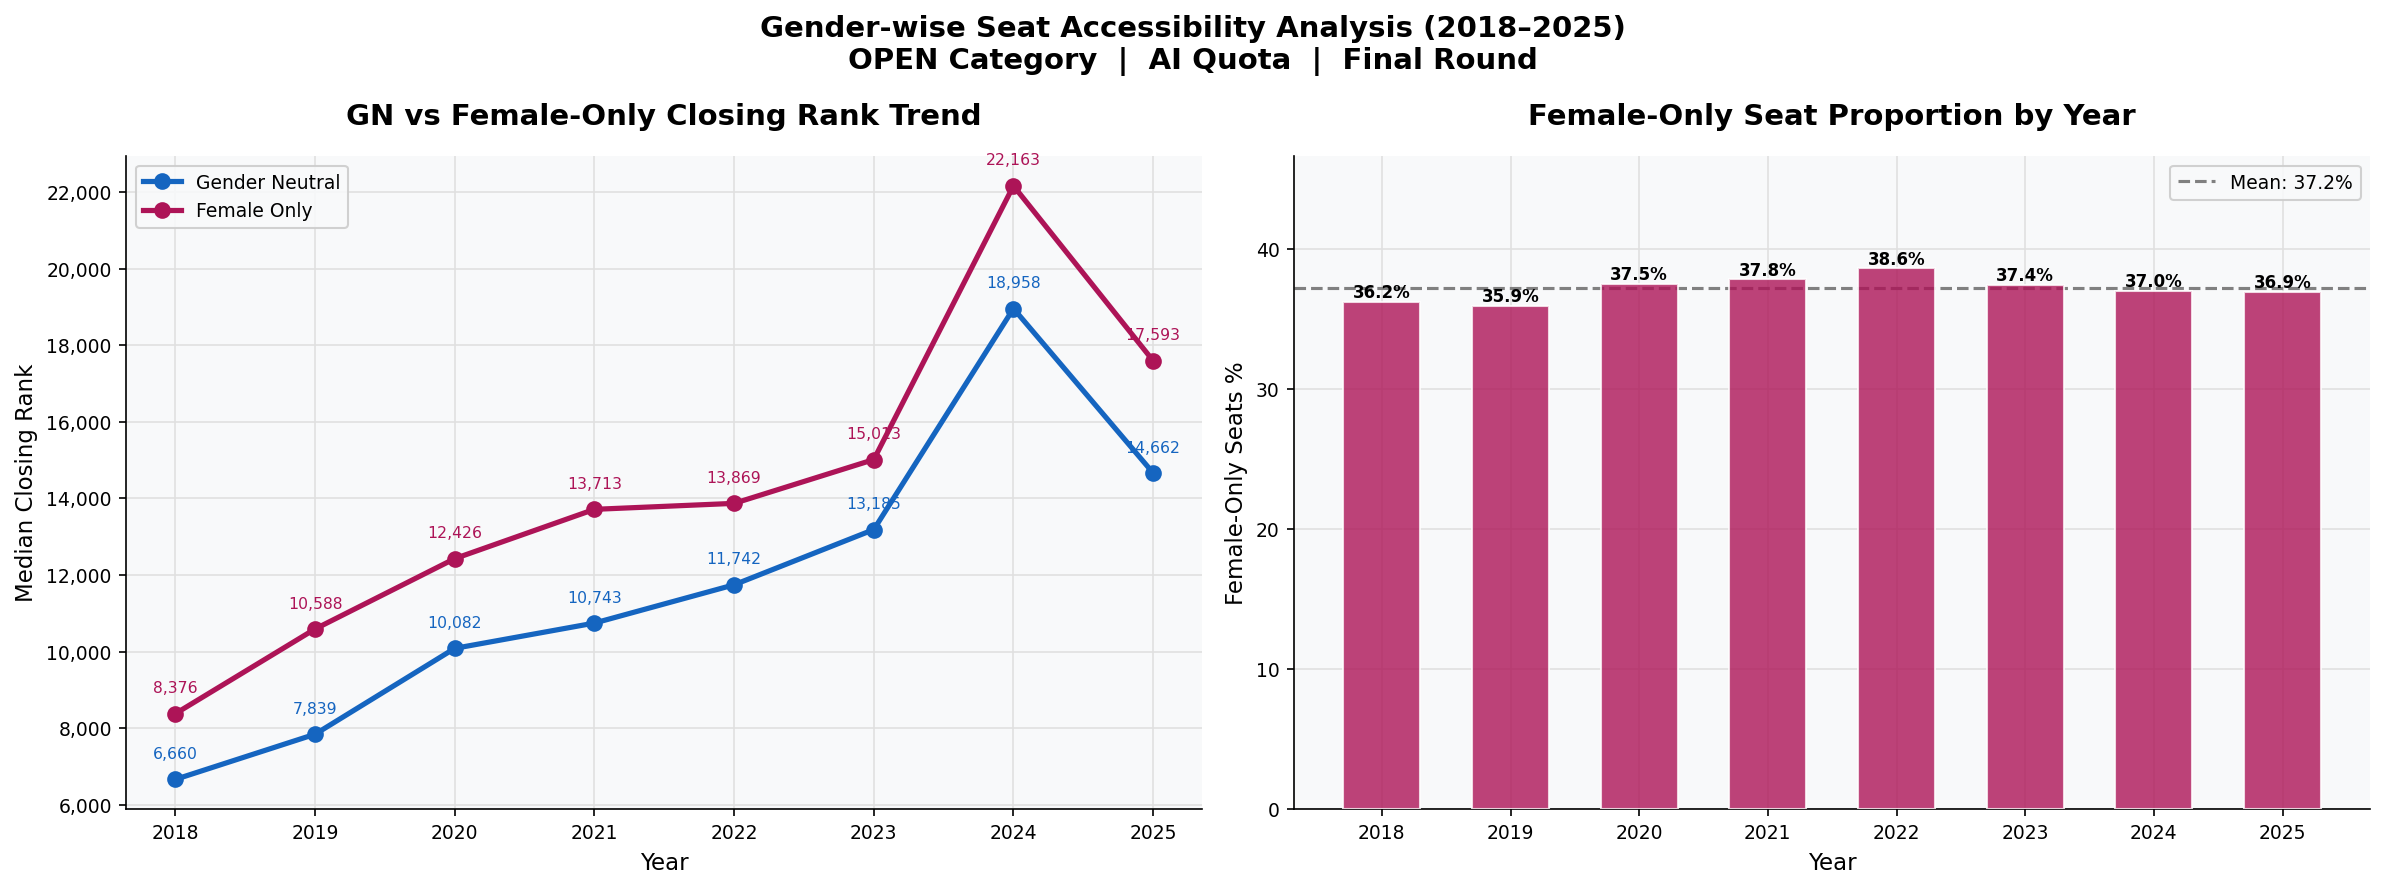

In [11]:
# CHART PURPOSE: FO vs GN closing rank comparison over years
# CHART TYPE: Dual line with gap annotation

df_gender = df_with_last[
    (df_with_last['round'] == df_with_last['last_round']) &
    (df_with_last['is_special_round'] == False) &
    (df_with_last['quota'] == 'AI') &
    (df_with_last['is_pwd'] == False) &
    (df_with_last['category_base'] == 'OPEN')
].copy()

gender_trend = (
    df_gender.groupby(['year', 'gender_short'])['closing_rank']
    .median().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Gender-wise Seat Accessibility Analysis (2018–2025)\n'
    'OPEN Category  |  AI Quota  |  Final Round',
    fontsize=14, fontweight='bold'
)

gender_colors = {'GN': '#1565C0', 'FO': '#AD1457'}
gender_labels = {'GN': 'Gender Neutral', 'FO': 'Female Only'}

# ── Left: Trend lines ────────────────────────────────────────
for g in ['GN', 'FO']:
    data = gender_trend[gender_trend['gender_short']==g].sort_values('year')
    axes[0].plot(
        data['year'], data['closing_rank'],
        marker='o', linewidth=2.5, markersize=7,
        label=gender_labels[g], color=gender_colors[g], zorder=3
    )
    for _, row in data.iterrows():
        axes[0].annotate(
            f"{int(row['closing_rank']):,}",
            (row['year'], row['closing_rank']),
            textcoords='offset points',
            xytext=(0, 10), ha='center',
            fontsize=7.5, color=gender_colors[g]
        )

axes[0].set_title('GN vs Female-Only Closing Rank Trend')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Closing Rank')
axes[0].set_xticks(sorted(df_gender['year'].unique()))
axes[0].legend()
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'{int(x):,}')
)

# ── Right: Female seat proportion ────────────────────────────
fo_prop = (
    df[df['is_special_round']==False]
    .groupby(['year', 'gender_short']).size()
    .unstack(fill_value=0)
)
fo_prop['FO_pct'] = (
    fo_prop['FO'] / (fo_prop['FO'] + fo_prop['GN']) * 100
).round(1)

axes[1].bar(
    fo_prop.index, fo_prop['FO_pct'],
    color='#AD1457', edgecolor='white',
    width=0.6, alpha=0.8, zorder=3
)

axes[1].axhline(y=fo_prop['FO_pct'].mean(), color='gray',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {fo_prop['FO_pct'].mean():.1f}%")

for year, val in zip(fo_prop.index, fo_prop['FO_pct']):
    axes[1].text(year, val+0.3, f'{val}%',
                 ha='center', fontsize=8, fontweight='bold')

axes[1].set_title('Female-Only Seat Proportion by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Female-Only Seats %')
axes[1].set_xticks(sorted(df['year'].unique()))
axes[1].legend()
axes[1].set_ylim(0, fo_prop['FO_pct'].max() + 8)

plt.tight_layout()
save_fig('V7_gender_analysis.png')
plt.show()

In [12]:
# Print all saved figures
print("=" * 55)
print("PHASE 7 VISUALIZATION INVENTORY")
print("=" * 55)

figures_dir = os.path.join('..', 'reports', 'figures')
saved_files = sorted([
    f for f in os.listdir(figures_dir)
    if f.endswith('.png')
])

print(f"\nTotal charts saved: {len(saved_files)}")
print("\nChart files:")
for f in saved_files:
    size_kb = os.path.getsize(
        os.path.join(figures_dir, f)
    ) // 1024
    print(f"  {f:55} {size_kb:5} KB")

PHASE 7 VISUALIZATION INVENTORY

Total charts saved: 32

Chart files:
  01_records_per_year.png                                    55 KB
  02_records_by_institute_type.png                           86 KB
  03_category_gender_distribution.png                        81 KB
  04_institute_type_competitiveness.png                     109 KB
  05_competitiveness_trend_by_type.png                      146 KB
  06_seat_volume_by_type.png                                100 KB
  07_top15_competitive_colleges.png                         100 KB
  08_top5_per_tier.png                                      183 KB
  09_bottom5_per_tier.png                                   194 KB
  10_top15_competitive_programs.png                         109 KB
  11_program_trend.png                                      185 KB
  12_cse_ece_me_comparison.png                              183 KB
  13_category_distribution.png                               96 KB
  14_category_gap_analysis.png                             